# 🌳 Introdução às Árvores

Neste notebook, exploraremos um dos tipos mais importantes de grafos: **as árvores**.

## Objetivos

- Compreender a definição formal de árvore
- Entender árvores orientadas
- Explorar aplicações práticas
- Visualizar exemplos concretos

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Configuração de visualização
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

## 📖 Definições Fundamentais

### Árvore (Tree)

> **Definição**: Uma **árvore** é um grafo **conexo** que **não possui circuitos**.

Em outras palavras:
- ✅ Todos os vértices estão conectados
- ✅ Não existem ciclos (caminhos fechados)
- ✅ Existe exatamente um caminho entre qualquer par de vértices

### Árvore Orientada (Directed Tree)

> **Definição**: Uma **árvore orientada** é um grafo orientado conexo que não possui circuitos ou semi-circuitos.

- Semi-circuito: caminho que ignora a direção das arestas e forma um ciclo

## 🎯 Exemplo Visual: O que É e o que NÃO É uma Árvore

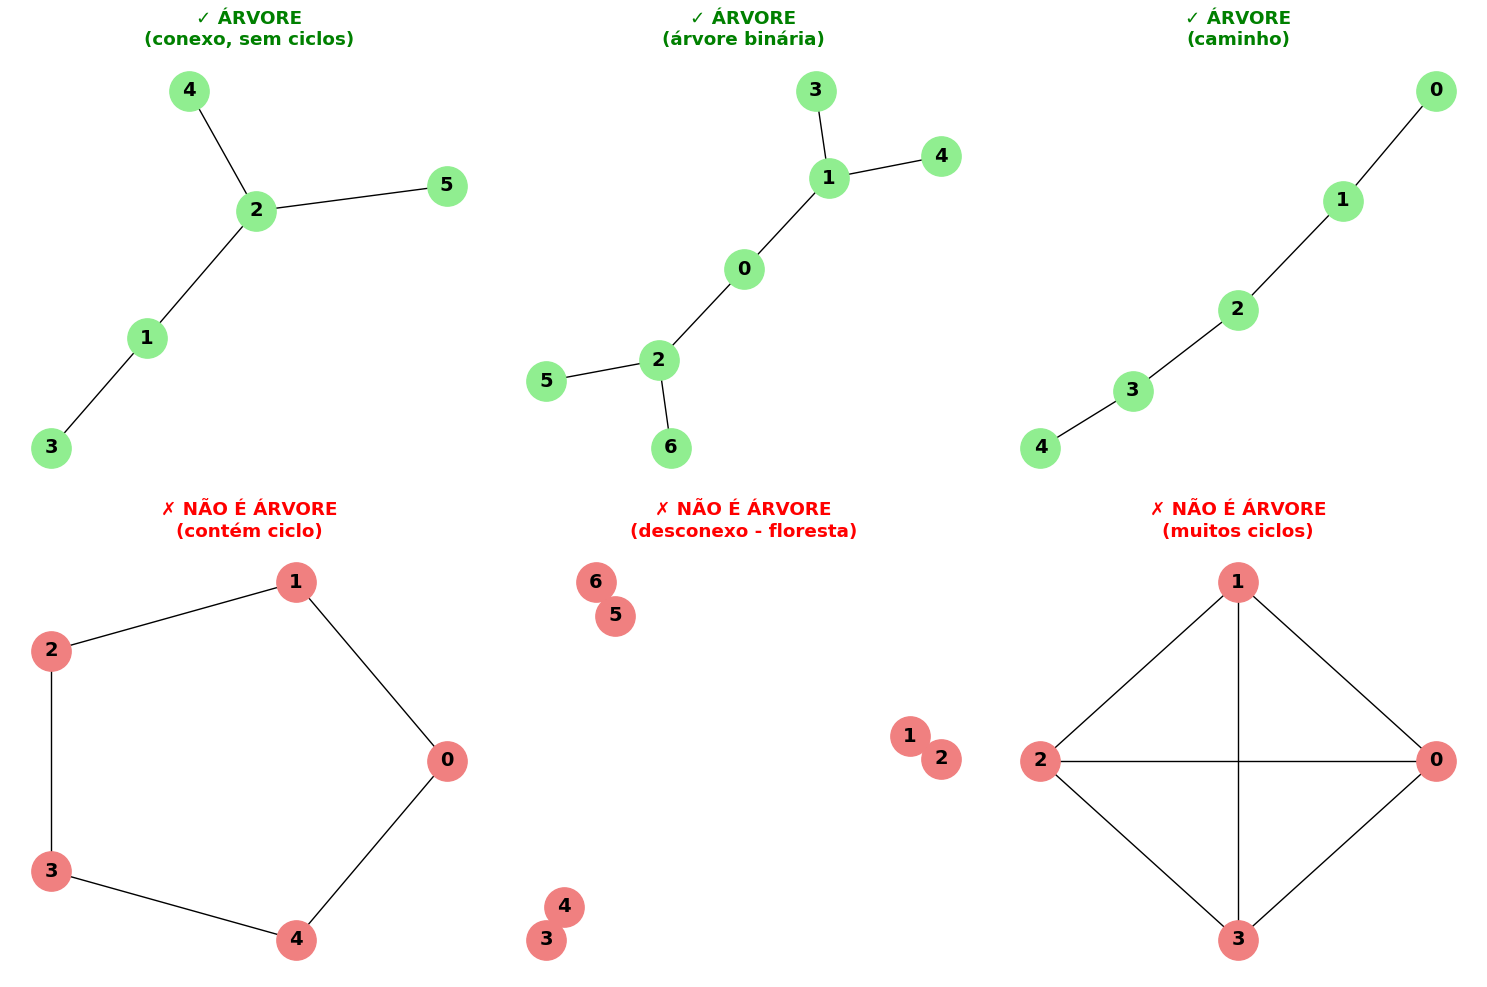


📊 Resumo:
  ✓ Árvore = Conexo + Sem Ciclos
  ✗ Não é árvore se tem ciclos ou é desconexo


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)

# 1. Árvore simples ✓
T1 = nx.Graph()
T1.add_edges_from([(1,2), (1,3), (2,4), (2,5)])
pos1 = nx.spring_layout(T1, seed=42)
nx.draw(T1, pos1, ax=axes[0,0], with_labels=True, node_color='lightgreen', 
        node_size=800, font_size=14, font_weight='bold')
axes[0,0].set_title('✓ ÁRVORE\n(conexo, sem ciclos)', fontweight='bold', color='green')

# 2. Árvore maior ✓
T2 = nx.balanced_tree(2, 2)  # árvore binária balanceada
pos2 = nx.spring_layout(T2, seed=42)
nx.draw(T2, pos2, ax=axes[0,1], with_labels=True, node_color='lightgreen',
        node_size=800, font_size=14, font_weight='bold')
axes[0,1].set_title('✓ ÁRVORE\n(árvore binária)', fontweight='bold', color='green')

# 3. Caminho (também é árvore) ✓
T3 = nx.path_graph(5)
pos3 = nx.spring_layout(T3, seed=42)
nx.draw(T3, pos3, ax=axes[0,2], with_labels=True, node_color='lightgreen',
        node_size=800, font_size=14, font_weight='bold')
axes[0,2].set_title('✓ ÁRVORE\n(caminho)', fontweight='bold', color='green')

# 4. Grafo com ciclo ✗
G1 = nx.cycle_graph(5)
pos4 = nx.circular_layout(G1)
nx.draw(G1, pos4, ax=axes[1,0], with_labels=True, node_color='lightcoral',
        node_size=800, font_size=14, font_weight='bold')
axes[1,0].set_title('✗ NÃO É ÁRVORE\n(contém ciclo)', fontweight='bold', color='red')

# 5. Grafo desconexo ✗
G2 = nx.Graph()
G2.add_edges_from([(1,2), (3,4), (5,6)])
pos5 = nx.spring_layout(G2, seed=42)
nx.draw(G2, pos5, ax=axes[1,1], with_labels=True, node_color='lightcoral',
        node_size=800, font_size=14, font_weight='bold')
axes[1,1].set_title('✗ NÃO É ÁRVORE\n(desconexo - floresta)', fontweight='bold', color='red')

# 6. Grafo completo K4 ✗
G3 = nx.complete_graph(4)
pos6 = nx.circular_layout(G3)
nx.draw(G3, pos6, ax=axes[1,2], with_labels=True, node_color='lightcoral',
        node_size=800, font_size=14, font_weight='bold')
axes[1,2].set_title('✗ NÃO É ÁRVORE\n(muitos ciclos)', fontweight='bold', color='red')
plt.show()

print("\n📊 Resumo:")
print("  ✓ Árvore = Conexo + Sem Ciclos")
print("  ✗ Não é árvore se tem ciclos ou é desconexo")

## 📏 Distância entre Vértices

> **Definição**: A **distância** $d(v, w)$ entre dois vértices $v$ e $w$ em um grafo $G$ é o **comprimento do menor caminho** entre $v$ e $w$.

### Propriedade Especial em Árvores

Em uma **árvore**, existe **exatamente um caminho** entre cada par de vértices. Portanto:

$$d(v, w) = \text{comprimento do único caminho entre } v \text{ e } w$$

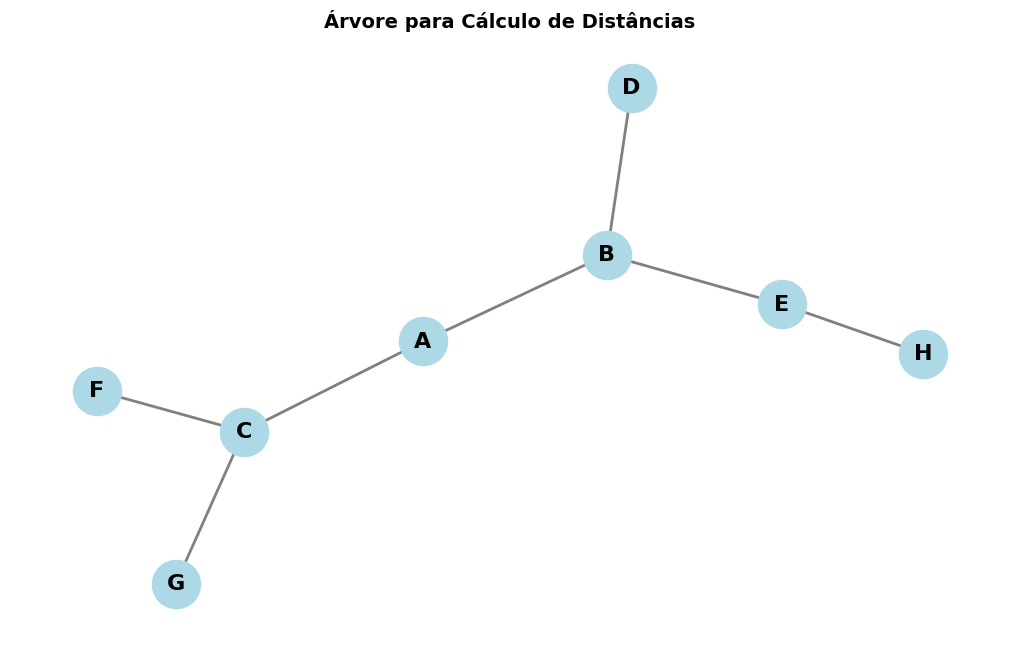


📏 Distâncias a partir do vértice A:
  d(A, B) = 1  →  Caminho: A → B
  d(A, C) = 1  →  Caminho: A → C
  d(A, D) = 2  →  Caminho: A → B → D
  d(A, E) = 2  →  Caminho: A → B → E
  d(A, F) = 2  →  Caminho: A → C → F
  d(A, G) = 2  →  Caminho: A → C → G
  d(A, H) = 3  →  Caminho: A → B → E → H

✓ Propriedade: Em uma árvore, existe EXATAMENTE UM caminho entre cada par de vértices


In [3]:
# Criar uma árvore e calcular distâncias
T = nx.Graph()
T.add_edges_from([
    ('A', 'B'), ('A', 'C'),
    ('B', 'D'), ('B', 'E'),
    ('C', 'F'), ('C', 'G'),
    ('E', 'H')
])

# Visualizar
pos = nx.spring_layout(T, seed=42)
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True, constrained_layout=True)
nx.draw(T, pos, with_labels=True, node_color='lightblue',
        node_size=1200, font_size=16, font_weight='bold', edge_color='gray', width=2, ax=ax)
ax.set_title('Árvore para Cálculo de Distâncias', fontsize=14, fontweight='bold')
plt.show()

# Calcular todas as distâncias a partir de 'A'
print("\n📏 Distâncias a partir do vértice A:")
print("="*40)
for node in T.nodes():
    if node != 'A':
        dist = nx.shortest_path_length(T, 'A', node)
        path = nx.shortest_path(T, 'A', node)
        print(f"  d(A, {node}) = {dist}  →  Caminho: {' → '.join(path)}")

# Verificar que só existe UM caminho
print("\n✓ Propriedade: Em uma árvore, existe EXATAMENTE UM caminho entre cada par de vértices")

## 🌍 Aplicações Práticas de Árvores

### 1. Construção de Rodovias

**Problema**: Conectar $n$ cidades com o mínimo de estradas.

**Solução**: Uma árvore com $n$ vértices tem **exatamente $n-1$ arestas** (menor número possível para manter conexão).

### 2. Instalação de Redes

- Redes de computadores
- Redes elétricas
- Sistemas de distribuição de água

**Por quê árvores?** Minimizam custo (menos conexões) mantendo comunicação total.

C:\Users\leona\AppData\Local\Temp\ipykernel_46060\2554045116.py:30: UserWarning: Glyph 128739 (\N{MOTORWAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\GitHub\DoutoradoCefet\TeoriaGrafos\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128739 (\N{MOTORWAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


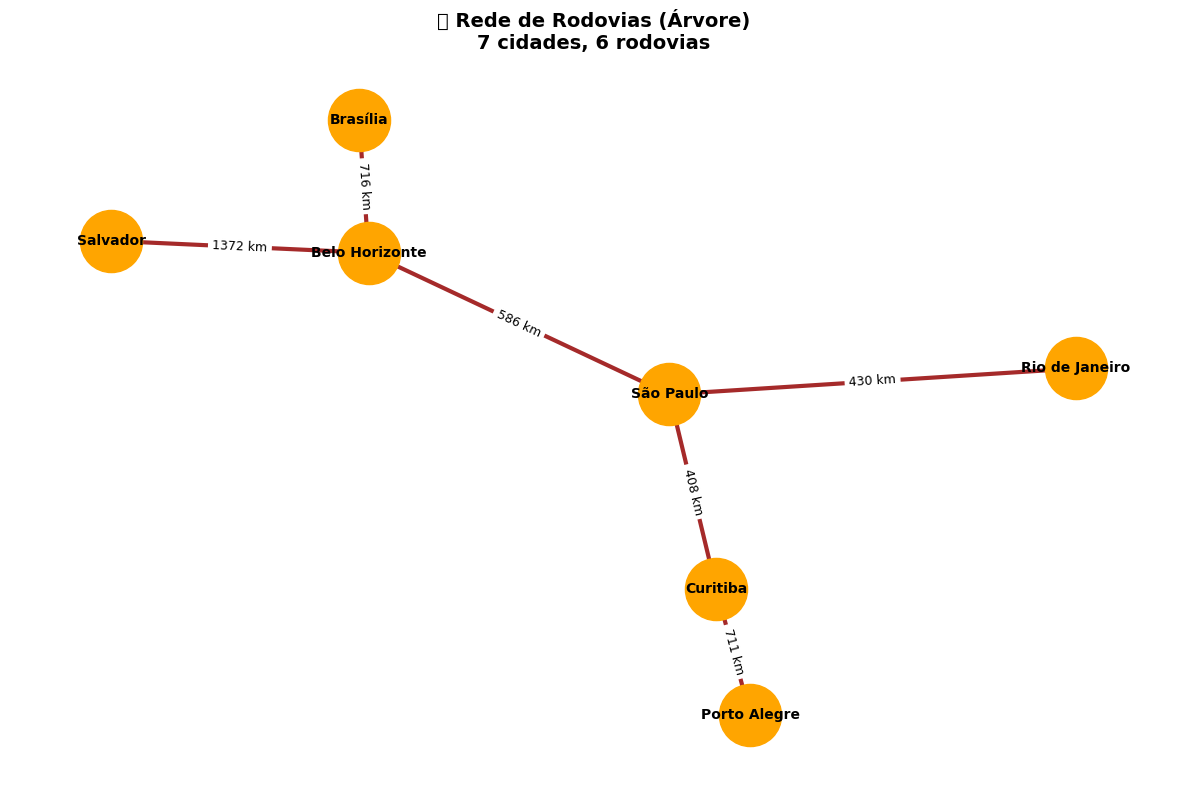


📊 Estatísticas:
  Vértices (cidades): 7
  Arestas (rodovias): 6
  Relação: n - 1 = 7 - 1 = 6 ✓
  É árvore? True
  Distância total: 4223 km


In [4]:
# Exemplo: Rede de cidades
cidades = ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Brasília', 
           'Curitiba', 'Porto Alegre', 'Salvador']

# Árvore de conexão (rodovias principais)
G_rodovias = nx.Graph()
G_rodovias.add_weighted_edges_from([
    ('São Paulo', 'Rio de Janeiro', 430),
    ('São Paulo', 'Curitiba', 408),
    ('São Paulo', 'Belo Horizonte', 586),
    ('Belo Horizonte', 'Brasília', 716),
    ('Belo Horizonte', 'Salvador', 1372),
    ('Curitiba', 'Porto Alegre', 711)
])

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True, constrained_layout=True)
pos = nx.spring_layout(G_rodovias, k=3, seed=42)
nx.draw_networkx_nodes(G_rodovias, pos, node_color='orange', node_size=2000)
nx.draw_networkx_labels(G_rodovias, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_rodovias, pos, width=3, edge_color='brown', ax=ax)

# Adicionar pesos (distâncias em km)
edge_labels = nx.get_edge_attributes(G_rodovias, 'weight')
edge_labels = {k: f"{v} km" for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(G_rodovias, pos, edge_labels, font_size=9, ax=ax)

ax.set_title('🛣️ Rede de Rodovias (Árvore)\n7 cidades, 6 rodovias', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

print(f"\n📊 Estatísticas:")
print(f"  Vértices (cidades): {G_rodovias.number_of_nodes()}")
print(f"  Arestas (rodovias): {G_rodovias.number_of_edges()}")
print(f"  Relação: n - 1 = {G_rodovias.number_of_nodes()} - 1 = {G_rodovias.number_of_edges()} ✓")
print(f"  É árvore? {nx.is_tree(G_rodovias)}")
print(f"  Distância total: {sum(nx.get_edge_attributes(G_rodovias, 'weight').values())} km")

## 🎮 Exemplo: Jogo da Velha (Tic-Tac-Toe)

**Modelagem**:
- **Vértices**: Estados do jogo
- **Arestas**: Transições entre estados (movimentos válidos)

A árvore de estados do jogo da velha é uma **árvore de decisão**.

C:\Users\leona\AppData\Local\Temp\ipykernel_46060\548937009.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
d:\GitHub\DoutoradoCefet\TeoriaGrafos\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127918 (\N{VIDEO GAME}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


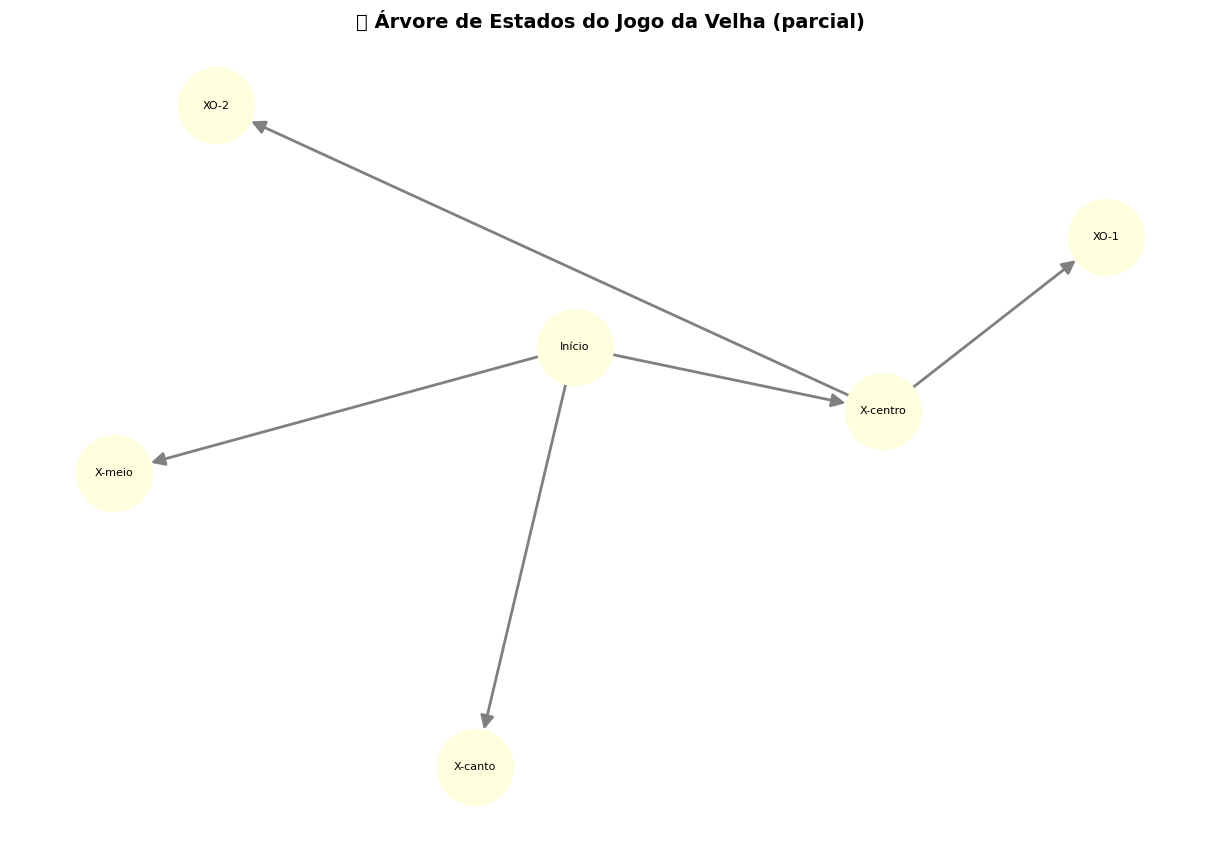


🎯 Árvore Completa do Jogo da Velha:
  - Até 9! = 362,880 estados possíveis (sem poda)
  - Com poda (vitórias/empates): ~5,478 estados
  - É uma árvore orientada!


In [5]:
# Árvore simplificada do jogo da velha (primeiros movimentos)
tictactoe = nx.DiGraph()

# Estado inicial
tictactoe.add_node('Início', label='[ ][ ][ ]\n[ ][ ][ ]\n[ ][ ][ ]')

# Primeiros movimentos possíveis do X (3 tipos por simetria)
tictactoe.add_node('X-centro', label='[ ][ ][ ]\n[ ][X][ ]\n[ ][ ][ ]')
tictactoe.add_node('X-canto', label='[X][ ][ ]\n[ ][ ][ ]\n[ ][ ][ ]')
tictactoe.add_node('X-meio', label='[ ][X][ ]\n[ ][ ][ ]\n[ ][ ][ ]')

tictactoe.add_edges_from([
    ('Início', 'X-centro'),
    ('Início', 'X-canto'),
    ('Início', 'X-meio')
])

# Alguns movimentos do O após X no centro
tictactoe.add_node('XO-1', label='[O][ ][ ]\n[ ][X][ ]\n[ ][ ][ ]')
tictactoe.add_node('XO-2', label='[ ][O][ ]\n[ ][X][ ]\n[ ][ ][ ]')
tictactoe.add_edges_from([
    ('X-centro', 'XO-1'),
    ('X-centro', 'XO-2')
])

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True, constrained_layout=True)
pos = nx.spring_layout(tictactoe, k=2, seed=42)
nx.draw(tictactoe, pos, with_labels=True, node_color='lightyellow',
        node_size=3000, font_size=8, arrows=True, arrowsize=20,
        edge_color='gray', width=2, ax=ax)
ax.set_title('🎮 Árvore de Estados do Jogo da Velha (parcial)', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

print("\n🎯 Árvore Completa do Jogo da Velha:")
print("  - Até 9! = 362,880 estados possíveis (sem poda)")
print("  - Com poda (vitórias/empates): ~5,478 estados")
print("  - É uma árvore orientada!")

## 👨‍👩‍👧‍👦 Exemplo: Árvore Genealógica

**Modelagem**:
- **Vértices**: Pessoas
- **Arestas**: Relação de parentesco em primeiro grau (pais ↔ filhos)

Uma árvore genealógica é naturalmente uma **árvore enraizada** (raiz = ancestral mais antigo).

C:\Users\leona\AppData\Local\Temp\ipykernel_46060\1451981612.py:26: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leona\AppData\Local\Temp\ipykernel_46060\1451981612.py:26: UserWarning: Glyph 128105 (\N{WOMAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leona\AppData\Local\Temp\ipykernel_46060\1451981612.py:26: UserWarning: Glyph 128103 (\N{GIRL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leona\AppData\Local\Temp\ipykernel_46060\1451981612.py:26: UserWarning: Glyph 128102 (\N{BOY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\GitHub\DoutoradoCefet\TeoriaGrafos\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\GitHub\DoutoradoCefet\TeoriaGrafos\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128105 (\N{WOMAN}) missing from font(s) De

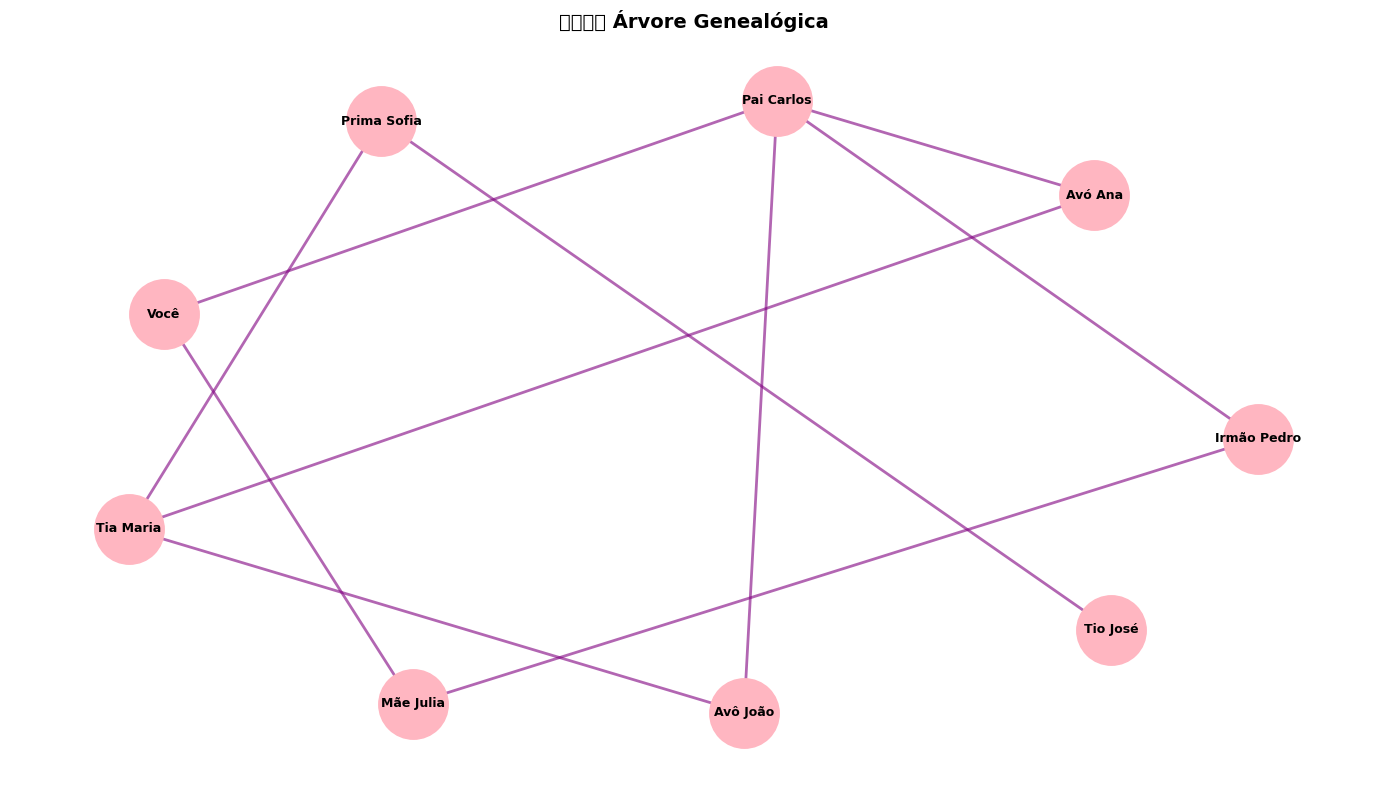


👪 Características:
  Pessoas (vértices): 9
  Relações (arestas): 10
  É árvore orientada? Sim (sentido: ancestrais → descendentes)


In [6]:
# Criar árvore genealógica
genealogia = nx.DiGraph()

genealogia.add_edges_from([
    ('Avô João', 'Pai Carlos'),
    ('Avô João', 'Tia Maria'),
    ('Avó Ana', 'Pai Carlos'),
    ('Avó Ana', 'Tia Maria'),
    ('Pai Carlos', 'Você'),
    ('Pai Carlos', 'Irmão Pedro'),
    ('Mãe Julia', 'Você'),
    ('Mãe Julia', 'Irmão Pedro'),
    ('Tia Maria', 'Prima Sofia'),
    ('Tio José', 'Prima Sofia')
])

fig, ax = plt.subplots(figsize=(14, 8), constrained_layout=True, constrained_layout=True)
pos = nx.spring_layout(genealogia, k=3, seed=100)
nx.draw_networkx_nodes(genealogia, pos, node_color='lightpink', node_size=2500)
nx.draw_networkx_labels(genealogia, pos, font_size=9, font_weight='bold')
nx.draw_networkx_edges(genealogia, pos, arrows=True, arrowsize=20, 
                       edge_color='purple', width=2, alpha=0.6, ax=ax)

ax.set_title('👨‍👩‍👧‍👦 Árvore Genealógica', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

print("\n👪 Características:")
print(f"  Pessoas (vértices): {genealogia.number_of_nodes()}")
print(f"  Relações (arestas): {genealogia.number_of_edges()}")
print(f"  É árvore orientada? Sim (sentido: ancestrais → descendentes)")

## ✅ Verificando se um Grafo é Árvore

In [7]:
def eh_arvore(G):
    """
    Verifica se um grafo G é uma árvore.
    Uma árvore deve ser:
    1. Conexa
    2. Sem ciclos
    3. Ter n-1 arestas (onde n é o número de vértices)
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()
    
    # Condição 1: Conexo
    conexo = nx.is_connected(G)
    
    # Condição 2: Sem ciclos
    try:
        ciclos = list(nx.simple_cycles(G.to_directed()))
        sem_ciclos = len(ciclos) == 0
    except:
        sem_ciclos = True
    
    # Condição 3: n-1 arestas
    arestas_corretas = (m == n - 1)
    
    print(f"\n🔍 Análise do Grafo:")
    print(f"  Vértices (n): {n}")
    print(f"  Arestas (m): {m}")
    print(f"  Conexo? {conexo} {'✓' if conexo else '✗'}")
    print(f"  Sem ciclos? {sem_ciclos} {'✓' if sem_ciclos else '✗'}")
    print(f"  m = n-1? {m} = {n-1}? {arestas_corretas} {'✓' if arestas_corretas else '✗'}")
    
    eh_arvore = conexo and sem_ciclos and arestas_corretas
    print(f"\n  → É ÁRVORE? {eh_arvore} {'🌳✓' if eh_arvore else '✗'}")
    
    return eh_arvore

# Testar com diferentes grafos
print("="*50)
print("TESTE 1: Árvore válida")
print("="*50)
T_valida = nx.Graph([(1,2), (1,3), (2,4), (2,5)])
eh_arvore(T_valida)

print("\n" + "="*50)
print("TESTE 2: Grafo com ciclo")
print("="*50)
G_ciclo = nx.cycle_graph(5)
eh_arvore(G_ciclo)

print("\n" + "="*50)
print("TESTE 3: Grafo desconexo (floresta)")
print("="*50)
G_desconexo = nx.Graph([(1,2), (3,4)])
eh_arvore(G_desconexo)

TESTE 1: Árvore válida

🔍 Análise do Grafo:
  Vértices (n): 5
  Arestas (m): 4
  Conexo? True ✓
  Sem ciclos? False ✗
  m = n-1? 4 = 4? True ✓

  → É ÁRVORE? False ✗

TESTE 2: Grafo com ciclo

🔍 Análise do Grafo:
  Vértices (n): 5
  Arestas (m): 5
  Conexo? True ✓
  Sem ciclos? False ✗
  m = n-1? 5 = 4? False ✗

  → É ÁRVORE? False ✗

TESTE 3: Grafo desconexo (floresta)

🔍 Análise do Grafo:
  Vértices (n): 4
  Arestas (m): 2
  Conexo? False ✗
  Sem ciclos? False ✗
  m = n-1? 2 = 3? False ✗

  → É ÁRVORE? False ✗


False

## 🎯 Resumo

### Definições

| Conceito | Definição |
|----------|----------|
| **Árvore** | Grafo **conexo** sem **circuitos** |
| **Árvore Orientada** | Grafo orientado conexo sem circuitos/semi-circuitos |
| **Distância d(v,w)** | Comprimento do menor (único) caminho entre v e w |

### Aplicações

- 🛣️ Construção de rodovias
- 🌐 Redes de computadores
- ⚡ Redes elétricas
- 🎮 Árvores de decisão (jogos)
- 👨‍👩‍👧‍👦 Árvores genealógicas

### Propriedade Fundamental

> Em uma árvore com $n$ vértices, há **exatamente $n-1$ arestas**.

### Próximo Notebook

No próximo notebook, exploraremos as **propriedades formais** das árvores e veremos que existem **5 definições equivalentes** para caracterizar uma árvore!

## 📝 Exercícios

1. Crie uma árvore com 8 vértices e verifique que ela tem 7 arestas.
2. Calcule a distância entre todos os pares de vértices em uma árvore de sua escolha.
3. Modele a estrutura hierárquica de uma empresa como uma árvore.
4. Crie uma árvore que representa o sistema de diretórios do seu computador.
5. Implemente uma função que conte o número de caminhos de comprimento $k$ em uma árvore.